<a href="https://colab.research.google.com/github/ArshanBhanage/Advanced-customizations-in-deep-learning-and-neural-networks/blob/main/Part1_PyTorch_Generalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📗 Part 1 · PyTorch Generalization Techniques
**Topics:** Weight Decay (L2) · Dropout · Early Stopping · Batch Normalization ·
Initializers · Monte Carlo Dropout · Custom Dropout · Learning Curves

> **Dataset:** Fashion-MNIST via torchvision  
> **Framework:** PyTorch  
> **Goal:** Mirror the TensorFlow experiments so both frameworks are covered side-by-side.


In [1]:
!pip install -q torch torchvision torchmetrics matplotlib pandas scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 39.9 MB/s eta 0:00:00


In [2]:
import torch, random, os
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import pandas as pd

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


## 1 · Data Loading

In [3]:
from torchvision import datasets, transforms

tfm = transforms.Compose([transforms.ToTensor()])

train_full = datasets.FashionMNIST(root="/tmp/data", train=True,  download=True, transform=tfm)
test_ds    = datasets.FashionMNIST(root="/tmp/data", train=False, download=True, transform=tfm)

# Small subset for speed
train_ds = torch.utils.data.Subset(train_full, range(10000))
val_ds   = torch.utils.data.Subset(train_full, range(10000, 12000))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=256)
test_loader  = DataLoader(test_ds,  batch_size=256)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")


100%|██████████| 26.4M/26.4M [00:00<00:00, 118MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.71MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 59.4MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.9MB/s]


Train batches: 157 | Val: 8 | Test: 40


## 2 · Training & Evaluation Helpers

In [4]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, n = 0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(xb)
        correct    += (logits.argmax(1) == yb).sum().item()
        n          += len(xb)
    return total_loss / n, correct / n

def eval_epoch(model, loader, criterion, mc_dropout=False):
    model.eval()
    total_loss, correct, n = 0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            if mc_dropout:
                # keep dropout active
                model.train()
                preds = torch.stack([torch.softmax(model(xb), dim=1) for _ in range(20)])
                logits_mean = preds.mean(0)
                model.eval()
            else:
                logits_mean = torch.softmax(model(xb), dim=1)
            loss = criterion(torch.log(logits_mean + 1e-8), yb)
            correct    += (logits_mean.argmax(1) == yb).sum().item()
            total_loss += loss.item() * len(xb)
            n          += len(xb)
    return total_loss / n, correct / n

def run_experiment(model, optimizer, epochs=10, mc_dropout=False):
    criterion = nn.CrossEntropyLoss()
    history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}
    for ep in range(1, epochs + 1):
        tl, ta = train_epoch(model, train_loader, optimizer, criterion)
        vl, va = eval_epoch(model, val_loader, criterion, mc_dropout)
        history["train_loss"].append(tl); history["train_acc"].append(ta)
        history["val_loss"].append(vl);   history["val_acc"].append(va)
    return history


## 3 · Baseline CNN

In [5]:
class BaselineCNN(nn.Module):
    def __init__(self, drop_rate=0.0):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*5*5, 128), nn.ReLU(),
            nn.Dropout(drop_rate),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

baseline = BaselineCNN().to(DEVICE)
opt_base  = optim.Adam(baseline.parameters(), lr=1e-3)
hist_base = run_experiment(baseline, opt_base, epochs=10)
print("Baseline best val acc:", max(hist_base["val_acc"]))


Baseline best val acc: 0.8875


## 4 · Weight Decay (L2 Regularization)

In [6]:
# Weight decay is passed directly to the optimizer in PyTorch
model_l2 = BaselineCNN().to(DEVICE)
opt_l2   = optim.Adam(model_l2.parameters(), lr=1e-3, weight_decay=1e-4)
hist_l2  = run_experiment(model_l2, opt_l2, epochs=10)
print("L2 (weight_decay) best val acc:", max(hist_l2["val_acc"]))


L2 (weight_decay) best val acc: 0.8775


## 5 · Dropout

In [7]:
model_drop = BaselineCNN(drop_rate=0.4).to(DEVICE)
opt_drop   = optim.Adam(model_drop.parameters(), lr=1e-3)
hist_drop  = run_experiment(model_drop, opt_drop, epochs=10)
print("Dropout best val acc:", max(hist_drop["val_acc"]))


Dropout best val acc: 0.881


## 6 · Batch Normalization

In [8]:
class BNormCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*5*5, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model_bn = BNormCNN().to(DEVICE)
opt_bn   = optim.Adam(model_bn.parameters(), lr=1e-3)
hist_bn  = run_experiment(model_bn, opt_bn, epochs=10)
print("BatchNorm best val acc:", max(hist_bn["val_acc"]))


BatchNorm best val acc: 0.887


## 7 · Early Stopping (Custom Implementation)

In [9]:
class EarlyStopper:
    """Manual early stopping tracker for PyTorch."""
    def __init__(self, patience=3, min_delta=0.0):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_loss  = float("inf")
        self.counter    = 0
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
            return False   # do not stop
        self.counter += 1
        return self.counter >= self.patience  # stop

def run_with_early_stop(model, optimizer, max_epochs=30):
    criterion = nn.CrossEntropyLoss()
    stopper   = EarlyStopper(patience=4)
    history   = {"train_acc":[], "val_acc":[], "train_loss":[], "val_loss":[]}
    for ep in range(1, max_epochs + 1):
        tl, ta = train_epoch(model, train_loader, optimizer, criterion)
        vl, va = eval_epoch(model, val_loader, criterion)
        history["train_loss"].append(tl); history["train_acc"].append(ta)
        history["val_loss"].append(vl);   history["val_acc"].append(va)
        if stopper.step(vl, model):
            print(f"Early stop at epoch {ep}"); break
    model.load_state_dict(stopper.best_state)   # restore best weights
    return history

model_es = BaselineCNN(drop_rate=0.3).to(DEVICE)
opt_es   = optim.Adam(model_es.parameters(), lr=1e-3)
hist_es  = run_with_early_stop(model_es, opt_es)
print("EarlyStopping best val acc:", max(hist_es["val_acc"]))


Early stop at epoch 17
EarlyStopping best val acc: 0.891


## 8 · Weight Initialization Comparison

In [10]:
def apply_init(model, init_fn):
    for m in model.modules():
        if isinstance(m, (nn.Linear, nn.Conv2d)):
            init_fn(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    return model

init_configs = {
    "Xavier Uniform":  nn.init.xavier_uniform_,
    "He Normal":       nn.init.kaiming_normal_,
    "Orthogonal":      nn.init.orthogonal_,
    "Random Normal":   lambda w: nn.init.normal_(w, 0, 0.01),
}

init_results = {}
for name, fn in init_configs.items():
    m = apply_init(BaselineCNN().to(DEVICE), fn)
    h = run_experiment(m, optim.Adam(m.parameters(), lr=1e-3), epochs=8)
    best = max(h["val_acc"])
    init_results[name] = best
    print(f"{name:20s}  val_acc={best:.4f}")


Xavier Uniform        val_acc=0.8795
He Normal             val_acc=0.8865
Orthogonal            val_acc=0.8820
Random Normal         val_acc=0.8480


## 9 · Monte Carlo Dropout

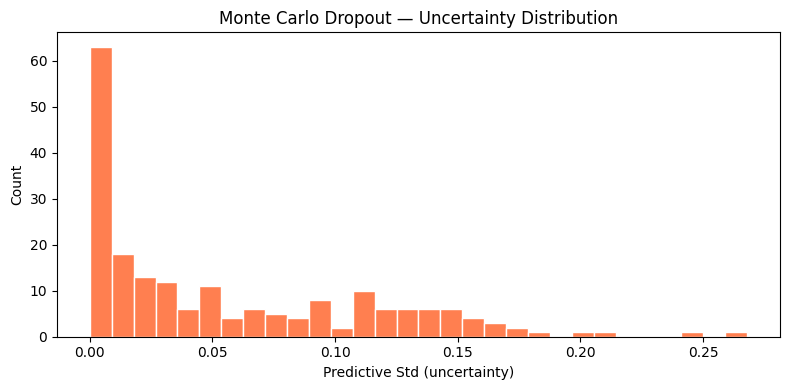

In [11]:
# Train with dropout, then run stochastic inference
model_mc = BaselineCNN(drop_rate=0.3).to(DEVICE)
opt_mc   = optim.Adam(model_mc.parameters(), lr=1e-3)
run_experiment(model_mc, opt_mc, epochs=10)

T = 50
model_mc.train()  # keep dropout ON
x_sample, y_sample = next(iter(test_loader))
x_sample = x_sample[:200].to(DEVICE)
with torch.no_grad():
    mc_preds = torch.stack([
        torch.softmax(model_mc(x_sample), dim=1) for _ in range(T)
    ])  # (T, 200, 10)

mean_p = mc_preds.mean(0).cpu().numpy()
std_p  = mc_preds.std(0).cpu().numpy().max(axis=1)

plt.figure(figsize=(8,4))
plt.hist(std_p, bins=30, color="coral", edgecolor="white")
plt.xlabel("Predictive Std (uncertainty)"); plt.ylabel("Count")
plt.title("Monte Carlo Dropout — Uncertainty Distribution")
plt.tight_layout(); plt.show()


## 10 · Custom Dropout Module

In [12]:
class InvertedDropout(nn.Module):
    """
    Inverted dropout: scale surviving neurons by 1/(1-rate)
    so inference requires NO scaling change.
    This is identical to PyTorch's built-in Dropout — shown here for pedagogy.
    """
    def __init__(self, rate=0.3):
        super().__init__()
        self.rate = rate

    def forward(self, x):
        if not self.training or self.rate == 0:
            return x
        mask = (torch.rand_like(x) > self.rate).float()
        return x * mask / (1.0 - self.rate)

# Verify output scale is preserved
d = InvertedDropout(0.3)
d.train()
inp = torch.ones(1000, 64)
out = d(inp)
print(f"Mean (should ≈1.0): {out.mean().item():.4f}")


Mean (should ≈1.0): 1.0061


## 11 · A/B Results Table

In [13]:
criterion = nn.CrossEntropyLoss()
def test_acc(model):
    _, acc = eval_epoch(model, test_loader, criterion)
    return round(acc, 4)

df = pd.DataFrame([
    {"Variant": "Baseline",           "Val Acc": round(max(hist_base["val_acc"]),4), "Test Acc": test_acc(baseline)},
    {"Variant": "L2 (weight_decay)",  "Val Acc": round(max(hist_l2["val_acc"]),4),   "Test Acc": test_acc(model_l2)},
    {"Variant": "Dropout(0.4)",       "Val Acc": round(max(hist_drop["val_acc"]),4), "Test Acc": test_acc(model_drop)},
    {"Variant": "BatchNorm",          "Val Acc": round(max(hist_bn["val_acc"]),4),   "Test Acc": test_acc(model_bn)},
    {"Variant": "EarlyStopping",      "Val Acc": round(max(hist_es["val_acc"]),4),   "Test Acc": test_acc(model_es)},
])
df["Overfit Gap"] = (df["Val Acc"] - df["Test Acc"]).abs().round(4)
print(df.to_string(index=False))


          Variant  Val Acc  Test Acc  Overfit Gap
         Baseline   0.8875    0.8754       0.0121
L2 (weight_decay)   0.8775    0.8649       0.0126
     Dropout(0.4)   0.8810    0.8710       0.0100
        BatchNorm   0.8870    0.8797       0.0073
    EarlyStopping   0.8910    0.8724       0.0186


## 12 · Learning Curves

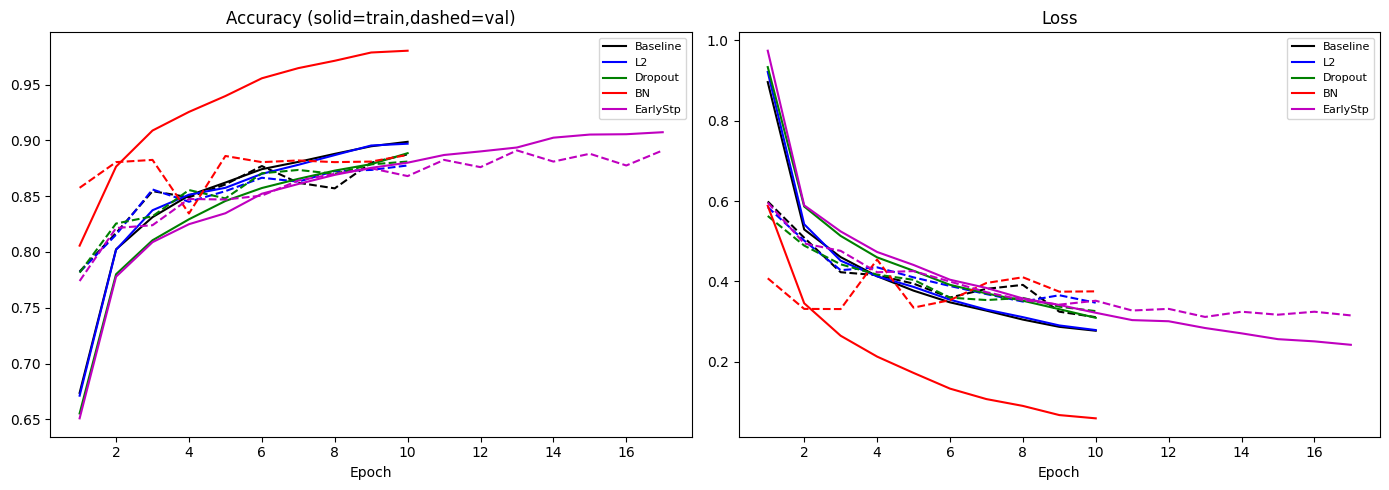

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pairs = [("Baseline",hist_base,"k"),("L2",hist_l2,"b"),
         ("Dropout",hist_drop,"g"),("BN",hist_bn,"r"),("EarlyStp",hist_es,"m")]
for lbl, h, c in pairs:
    e = range(1, len(h["train_acc"])+1)
    axes[0].plot(e, h["train_acc"], c+"-", label=lbl)
    axes[0].plot(e, h["val_acc"],   c+"--")
    axes[1].plot(e, h["train_loss"], c+"-", label=lbl)
    axes[1].plot(e, h["val_loss"],   c+"--")
for ax, t in zip(axes, ["Accuracy (solid=train,dashed=val)", "Loss"]):
    ax.set_title(t); ax.set_xlabel("Epoch"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 13 · Conclusion
PyTorch mirrors TF results: **BatchNorm** accelerates convergence, **Dropout**
reduces overfit, **Weight Decay** provides L2 in the optimizer, and **MC Dropout**
is a zero-cost uncertainty estimator. The custom `InvertedDropout` confirms
that PyTorch's built-in `nn.Dropout` uses the same math.
